In [43]:
import learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [55]:
df_train = pd.read_csv("../data/USA_Housing.csv")
print(df_train.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [3]:
missing_count = (df_train.isnull().sum() / len(df_train)) * 100
missing_count = missing_count[missing_count > 0]
print(missing_count)

Series([], dtype: float64)


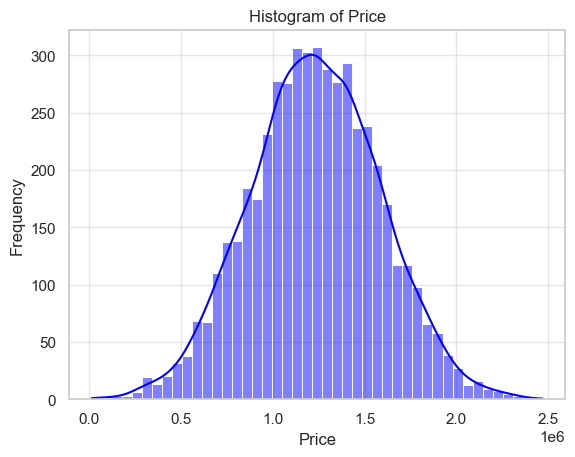

In [37]:
sns.histplot(df_train['Price'], kde=True, color='blue')
plt.title('Histogram of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

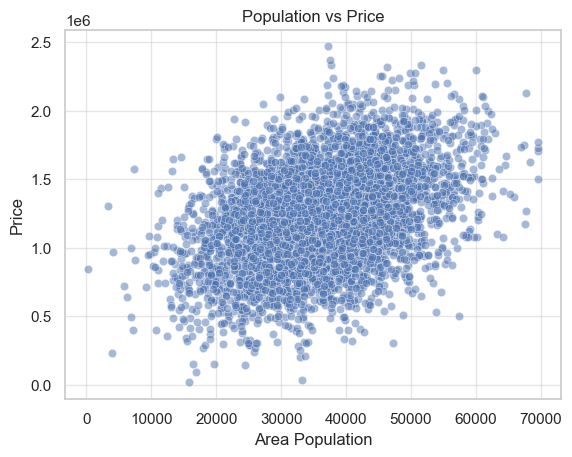

In [30]:
sns.scatterplot(data=df_train, x='Area Population', y='Price', alpha=0.5)
plt.title('Population vs Price')
plt.show()

In [15]:
numeric_data = df_train.select_dtypes(include = [np.number])
categorical_data = df_train.select_dtypes(exclude = [np.number])
print('There are {0} numerical and {1} categorical features in the training data'.
      format(numeric_data.shape[1], categorical_data.shape[1]))

There are 6 numerical and 1 categorical features in the training data


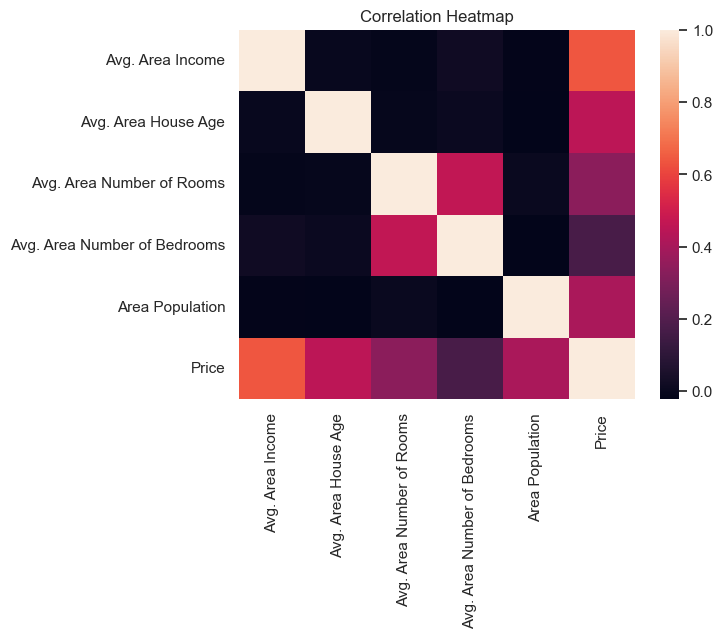

In [29]:
corr = numeric_data.corr()
sns.heatmap(corr)
plt.title('Correlation Heatmap')
plt.show()

In [16]:
df_train.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

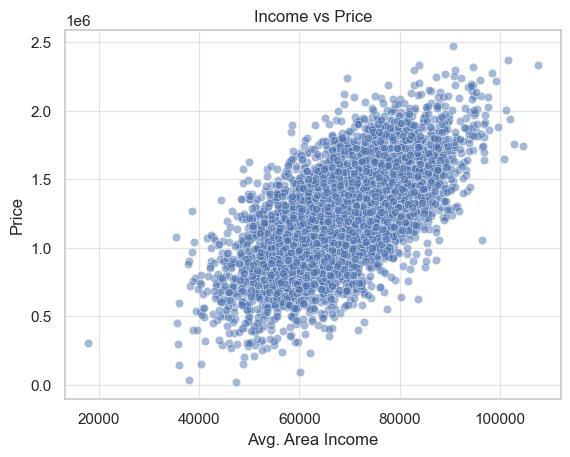

In [32]:
sns.scatterplot(data=df_train, x='Avg. Area Income', y='Price', alpha=0.5)
plt.title('Income vs Price')
plt.show()

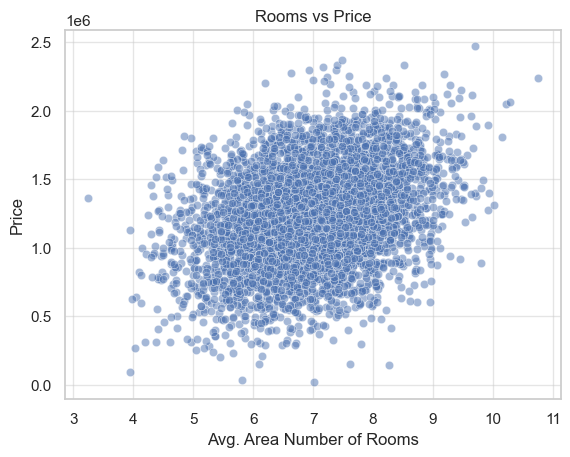

In [35]:
sns.scatterplot(data=df_train, x='Avg. Area Number of Rooms', y='Price', alpha=0.5)
plt.title('Rooms vs Price')
plt.show()

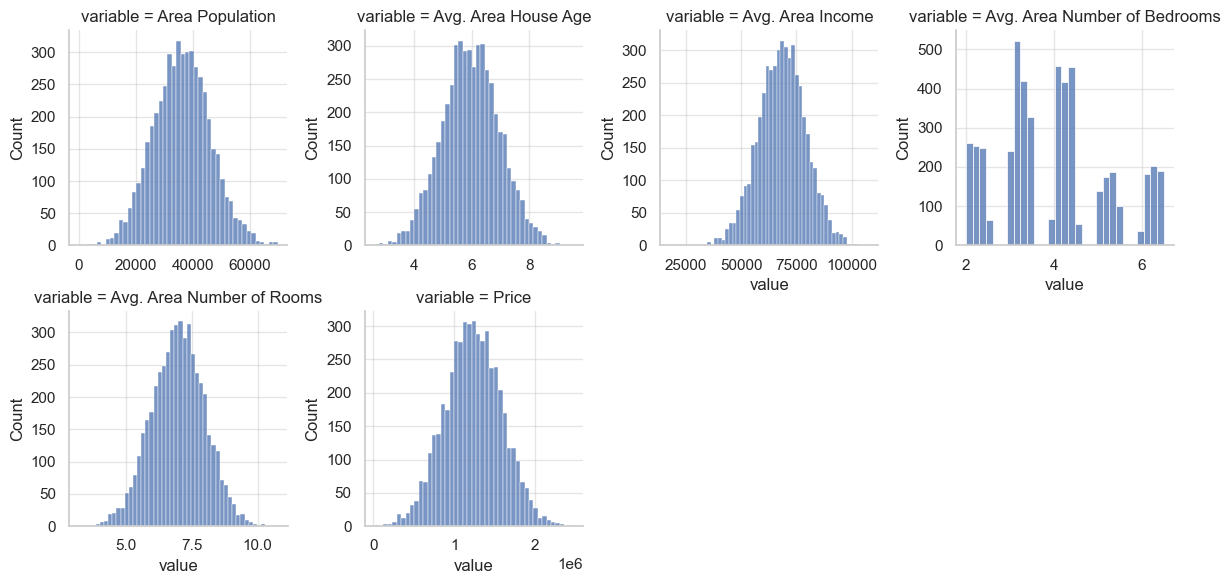

In [25]:
f = pd.melt(df_train , value_vars=sorted(numeric_data))
g = sns.FacetGrid(f, col='variable', col_wrap=4, sharex=False, sharey=False)
g = g.map(sns.histplot, 'value')

In [45]:
df = df_train.drop(columns=['Address'])
X = df.drop(columns=['Price'])
Y = df['Price']
print (X.columns.tolist())
print (X.shape)

['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']
(5000, 5)


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
        X,
        Y,
        test_size=0.2,
        random_state=42
    )
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 5)
(1000, 5)
(4000,)
(1000,)


In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
X_train_scaled_df = pd.DataFrame( X_train_scaled, columns = X_train.columns)
print(X_train_scaled_df.describe().round(2))

       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count           4000.00              4000.00                    4000.00   
mean              -0.00                -0.00                      -0.00   
std                1.00                 1.00                       1.00   
min               -4.75                -3.31                      -3.71   
25%               -0.67                -0.66                      -0.69   
50%                0.03                -0.01                       0.02   
75%                0.68                 0.68                       0.68   
max                3.37                 3.57                       3.27   

       Avg. Area Number of Bedrooms  Area Population  
count                       4000.00          4000.00  
mean                          -0.00             0.00  
std                            1.00             1.00  
min                           -1.62            -3.60  
25%                           -0.69            -0

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print ("Linear Regression")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.0f}")
print(f"R^2: {r2_score(y_test, y_pred_lr):.4f}")

Linear Regression
MAE: 80,879
RMSE: 100,444
R^2: 0.9180


In [52]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt=dt.predict(X_test_scaled)
print("\nDecision Tree Regressor")
print(f"MAE: {mean_absolute_error(y_test, y_pred_dt):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt)):,.0f}")
print(f"R^2: {r2_score(y_test, y_pred_dt):.4f}")


Decision Tree Regressor
MAE: 133,997
RMSE: 170,977
R^2: 0.7624


In [53]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("\n Random Forest Regressor")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f}")
print(f"R^2: {r2_score(y_test, y_pred_rf):.4f}")


 Random Forest Regressor
MAE: 94,645
RMSE: 120,252
R^2: 0.8825


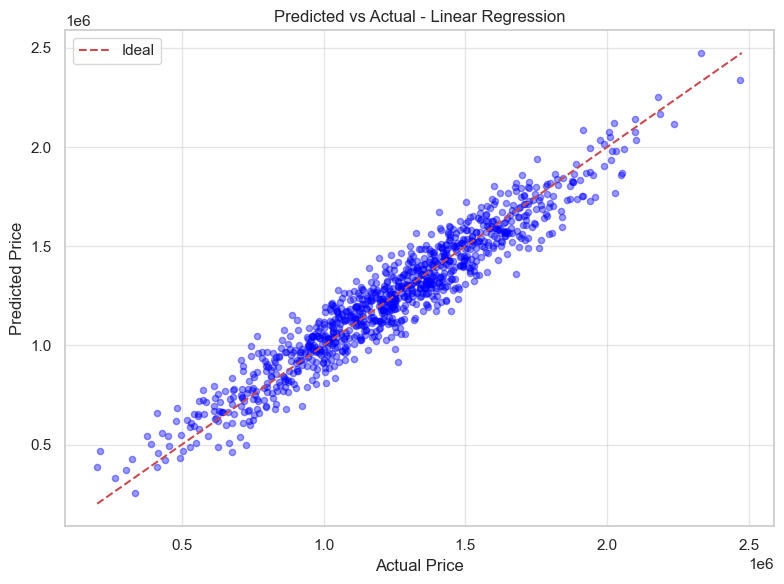

In [66]:
y_pred_best = y_pred_lr
best_model = lr
best_name = "Linear Regression"
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(y_test, y_pred_best, alpha=0.4, color='blue' , s=20)
min_val= min(y_test.min(), y_pred_best.min())
max_val= max(y_test.max(), y_pred_best.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Ideal')
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.set_title(f"Predicted vs Actual - {best_name}")
ax.legend()
plt.tight_layout()
plt.show()


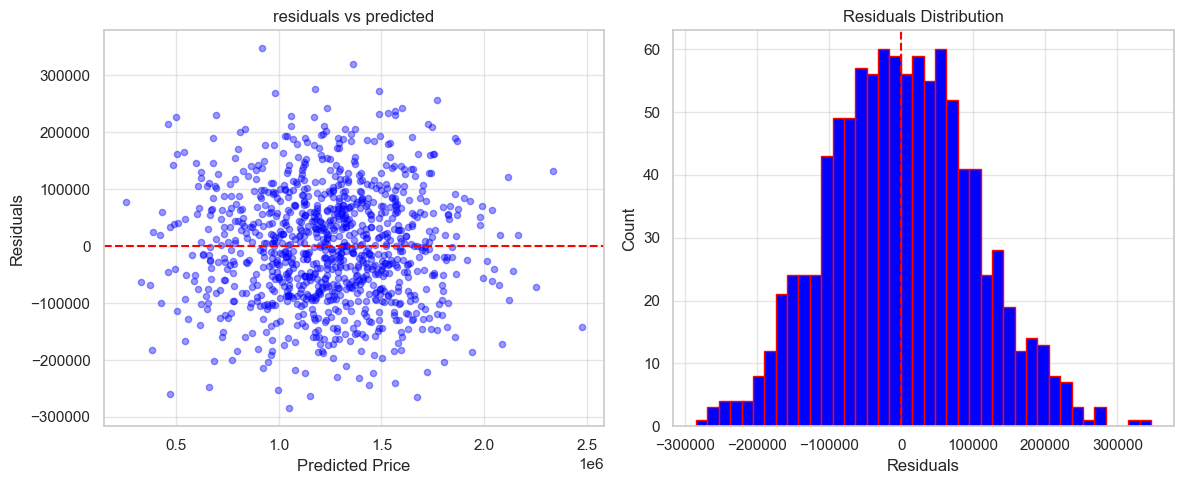

In [67]:
residuals = y_test - y_pred_best
fig, axes = plt.subplots(1, 2, figsize= (12, 5))
axes[0].scatter(y_pred_best, residuals, alpha=0.4, color='blue', s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('residuals vs predicted')
axes[1].hist(residuals, bins=40, color='blue', edgecolor='red')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals Distribution')
plt.tight_layout()
plt.show()

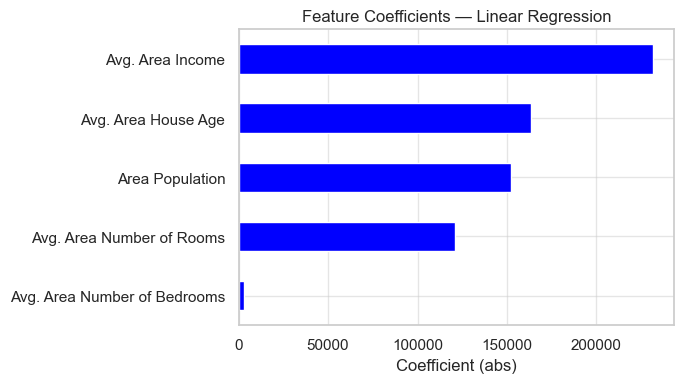

In [68]:
importances_lr = pd.Series(
    np.abs(lr.coef_),
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances_lr.plot(kind='barh', ax=ax, color='blue')
ax.set_title('Feature Coefficients — Linear Regression')
ax.set_xlabel('Coefficient (abs)')
plt.tight_layout()
plt.show()